# Milestone 6: Stable Diffusion for Alternate Product Lifestyle Images

This notebook covers the generative AI component of the capstone project.

## Objective
Using a pretrained diffusion model (**Stable Diffusion v1.5** via Hugging Face `diffusers`), we generate high-quality alternative lifestyle and advertising hero images conditioned on product titles and descriptions.

### Roadmap
1. **Environment Setup & Colab Compatibility**
2. **Prompt Engineering**: Designing prompts by combining product titles, descriptions, and photographic modifiers
3. **Stable Diffusion Pipeline**: Loading the pipeline in low-memory `float16` precision and running image generation
4. **Visualization**: Comparing original product images side-by-side with generated lifestyle images
5. **Short Reflection**: Analyzing image quality, text rendering issues, and failure modes

## 1. Setup, Environment Detection & Imports

In [ ]:
import sys
import os
from pathlib import Path

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab. Installing diffusers and accelerate libraries...")
    # Create folders

    os.makedirs('src', exist_ok=True)

    os.makedirs('data/processed', exist_ok=True)

    os.makedirs('data/plots', exist_ok=True)





    # Write data.py directly to Colab disk for imports

    data_py_content = 'import os\nimport json\nimport pandas as pd\nimport numpy as np\nimport requests\nfrom pathlib import Path\nfrom sklearn.model_selection import train_test_split\nfrom datasets import load_dataset\nimport io\nfrom PIL import Image\nfrom tqdm import tqdm\n\ndef load_amazon_data(category="All_Beauty"):\n    """\n    Loads raw reviews and metadata from Hugging Face datasets for a given category.\n    """\n    print(f"Loading reviews for {category}...")\n    reviews_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{category}", trust_remote_code=True)\n    reviews_df = pd.DataFrame(reviews_dataset[\'full\'])\n    \n    print(f"Loading metadata for {category}...")\n    meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_{category}", split="full", trust_remote_code=True)\n    meta_df = pd.DataFrame(meta_dataset)\n    \n    return reviews_df, meta_df\n\ndef clean_data(reviews_df, meta_df):\n    """\n    Performs basic cleaning of reviews and metadata:\n    - Handles missing values\n    - Formats data types (e.g. price, ratings)\n    - Extracts list elements from metadata where necessary\n    """\n    print("Cleaning metadata...")\n    # Clean price: convert to float if possible, or NaN\n    def clean_price(x):\n        if pd.isna(x):\n            return np.nan\n        if isinstance(x, (int, float)):\n            return float(x)\n        # If it\'s a string, try to parse\n        x_str = str(x).replace(\'$\', \'\').replace(\',\', \'\').strip()\n        try:\n            return float(x_str)\n        except ValueError:\n            return np.nan\n            \n    meta_df[\'price_cleaned\'] = meta_df[\'price\'].apply(clean_price)\n    \n    # Process images: extract the first image URL if it is a list of dicts/strings\n    def extract_image_url(images_val):\n        if not images_val or pd.isna(images_val):\n            return None\n            \n        def first_string(val):\n            if isinstance(val, list):\n                if len(val) > 0:\n                    first = val[0]\n                    if isinstance(first, str):\n                        return first\n                    elif isinstance(first, dict) and \'large\' in first:\n                        return first[\'large\']\n            elif isinstance(val, str):\n                return val\n            return None\n\n        if isinstance(images_val, dict):\n            for key in [\'large\', \'hi_res\', \'thumb\']:\n                if key in images_val:\n                    res = first_string(images_val[key])\n                    if res:\n                        return res\n            return None\n            \n        if isinstance(images_val, (list, np.ndarray)):\n            return first_string(list(images_val))\n            \n        return None\n\n    meta_df[\'image_url\'] = meta_df[\'images\'].apply(extract_image_url)\n    \n    # Clean descriptions (joining list of descriptions to single string)\n    def clean_description(desc):\n        if isinstance(desc, list):\n            return " ".join([str(d) for d in desc])\n        if pd.isna(desc):\n            return ""\n        return str(desc)\n        \n    meta_df[\'description_cleaned\'] = meta_df[\'description\'].apply(clean_description)\n    \n    print("Cleaning reviews...")\n    # Convert ratings and helpful votes\n    reviews_df[\'rating\'] = pd.to_numeric(reviews_df[\'rating\'], errors=\'coerce\')\n    vote_col = \'helpful_vote\' if \'helpful_vote\' in reviews_df.columns else \'helpful_votes\'\n    if vote_col in reviews_df.columns:\n        reviews_df[\'helpful_votes\'] = pd.to_numeric(reviews_df[vote_col], errors=\'coerce\').fillna(0).astype(int)\n    else:\n        reviews_df[\'helpful_votes\'] = 0\n    reviews_df[\'text_cleaned\'] = reviews_df[\'text\'].fillna("")\n    reviews_df[\'title_cleaned\'] = reviews_df[\'title\'].fillna("")\n    \n    return reviews_df, meta_df\n\ndef split_by_product(reviews_df, meta_df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42):\n    """\n    Splits the dataset by product (parent_asin) to prevent review-level leakage.\n    Ensures that all reviews and metadata for a product fall in the same split.\n    """\n    print("Splitting data by product...")\n    # We use parent_asin as the product identifier. If not present, we use asin.\n    prod_col = \'parent_asin\' if (\'parent_asin\' in meta_df.columns and \'parent_asin\' in reviews_df.columns) else \'asin\'\n    \n    # Get unique product IDs that exist in BOTH reviews and metadata\n    unique_products = list(set(meta_df[prod_col].unique()) & set(reviews_df[prod_col].unique()))\n    \n    # Train, validation, test split on products\n    train_prods, test_val_prods = train_test_split(\n        unique_products, \n        train_size=train_ratio, \n        random_state=random_seed\n    )\n    \n    val_relative_ratio = val_ratio / (val_ratio + test_ratio)\n    val_prods, test_prods = train_test_split(\n        test_val_prods, \n        train_size=val_relative_ratio, \n        random_state=random_seed\n    )\n    \n    train_prods_set = set(train_prods)\n    val_prods_set = set(val_prods)\n    test_prods_set = set(test_prods)\n    \n    # Split the metadata\n    meta_train = meta_df[meta_df[prod_col].isin(train_prods_set)]\n    meta_val = meta_df[meta_df[prod_col].isin(val_prods_set)]\n    meta_test = meta_df[meta_df[prod_col].isin(test_prods_set)]\n    \n    # Split the reviews\n    reviews_train = reviews_df[reviews_df[prod_col].isin(train_prods_set)]\n    reviews_val = reviews_df[reviews_df[prod_col].isin(val_prods_set)]\n    reviews_test = reviews_df[reviews_df[prod_col].isin(test_prods_set)]\n    \n    print(f"Split Summary (Products): Train={len(meta_train)}, Val={len(meta_val)}, Test={len(meta_test)}")\n    print(f"Split Summary (Reviews): Train={len(reviews_train)}, Val={len(reviews_val)}, Test={len(reviews_test)}")\n    \n    return (reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test)\n\ndef download_and_cache_images(meta_df, output_dir, max_images=5000):\n    """\n    Downloads and caches product images locally.\n    Returns a mapping of product ID (asin or parent_asin) to local file path.\n    """\n    output_path = Path(output_dir)\n    output_path.mkdir(parents=True, exist_ok=True)\n    \n    # Filter products that have valid image URLs\n    valid_images = meta_df[meta_df[\'image_url\'].notna() & (meta_df[\'image_url\'] != "")]\n    \n    # Sample up to max_images\n    if len(valid_images) > max_images:\n        valid_images = valid_images.sample(n=max_images, random_state=42)\n        \n    print(f"Downloading {len(valid_images)} product images to {output_path}...")\n    \n    image_paths = {}\n    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}\n    \n    # Determine the ID column\n    id_col = \'asin\' if \'asin\' in meta_df.columns else (\'parent_asin\' if \'parent_asin\' in meta_df.columns else \'asin\')\n    \n    for _, row in tqdm(valid_images.iterrows(), total=len(valid_images)):\n        prod_id = row[id_col]\n        url = row[\'image_url\']\n        ext = Path(url).suffix if Path(url).suffix in [\'.jpg\', \'.jpeg\', \'.png\'] else \'.jpg\'\n        local_file = output_path / f"{prod_id}{ext}"\n        \n        # Check if already downloaded\n        if local_file.exists():\n            image_paths[prod_id] = str(local_file)\n            continue\n            \n        try:\n            response = requests.get(url, headers=headers, timeout=10)\n            if response.status_code == 200:\n                img = Image.open(io.BytesIO(response.content))\n                # Convert to RGB if needed (handles RGBA/CMYK/etc)\n                if img.mode != \'RGB\':\n                    img = img.convert(\'RGB\')\n                img.save(local_file, "JPEG")\n                image_paths[prod_id] = str(local_file)\n            else:\n                image_paths[prod_id] = None\n        except Exception as e:\n            image_paths[prod_id] = None\n            \n    return image_paths\n'

    with open('src/data.py', 'w', encoding='utf-8') as f:

        f.write(data_py_content)

    sys.path.append(os.path.abspath('src'))

    !pip install "datasets>=2.16.0,<3.0.0" transformers diffusers accelerate gradio -q 2>/dev/null
    data_dir_path = 'data/processed'
    plots_dir_path = 'data/plots'
else:
    sys.path.append(os.path.abspath('../src'))
    data_dir_path = '../data/processed'
    plots_dir_path = '../data/plots'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Hugging Face diffusers
from diffusers import StableDiffusionPipeline

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Running in Google Colab. Installing diffusers and accelerate libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 5.6 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


PyTorch Version: 2.11.0+cu128
CUDA Available: True


## 2. Load Metadata Splits
We load the metadata splits and select a few product examples to generate lifestyle images for.

In [ ]:
from data import load_amazon_data, clean_data, split_by_product

# Check if processed splits exist
train_meta_path = Path(data_dir_path) / "meta_train.parquet"

if not train_meta_path.exists():
    print("Processed dataset splits not found. Loading and generating splits from scratch...")
    reviews_df, meta_df = load_amazon_data("All_Beauty")
    reviews_df, meta_df = clean_data(reviews_df, meta_df)

    splits = split_by_product(reviews_df, meta_df)
    (reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test) = splits

    # Save splits
    os.makedirs(data_dir_path, exist_ok=True)
    reviews_train.to_parquet(Path(data_dir_path) / "reviews_train.parquet", index=False)
    reviews_val.to_parquet(Path(data_dir_path) / "reviews_val.parquet", index=False)
    reviews_test.to_parquet(Path(data_dir_path) / "reviews_test.parquet", index=False)

    meta_train.to_parquet(Path(data_dir_path) / "meta_train.parquet", index=False)
    meta_val.to_parquet(Path(data_dir_path) / "meta_val.parquet", index=False)
    meta_test.to_parquet(Path(data_dir_path) / "meta_test.parquet", index=False)
else:
    print("Loading processed splits from disk...")
    meta_train = pd.read_parquet(Path(data_dir_path) / "meta_train.parquet")
    meta_test = pd.read_parquet(Path(data_dir_path) / "meta_test.parquet")

meta_all = pd.concat([meta_train, meta_test]).reset_index(drop=True)

# Sample a few products with descriptions
sample_products = meta_all[meta_all['description_cleaned'] != ""].head(3).copy()
sample_products[['title', 'store', 'description_cleaned']]

Processed dataset splits not found. Loading and generating splits from scratch...
Loading reviews for All_Beauty...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split: 0 examples [00:00, ? examples/s]

Loading metadata for All_Beauty...


Generating full split:   0%|          | 0/112590 [00:00<?, ? examples/s]

Cleaning metadata...
Cleaning reviews...
Splitting data by product...
Split Summary (Products): Train=78795, Val=16885, Test=16885
Split Summary (Reviews): Train=496519, Val=103980, Test=101029


,title,store,description_cleaned
4,Precision Plunger Bars for Cartridge Grips – 9...,Precision,The Precision Plunger Bars are designed to wor...
12,Small MONEY CLIP Leather Wallet ID Bag Cash Ho...,Buytra,Description Small MONEY CLIP Leather Wallet ID...
13,Nomade By Chloe,Chloe,new


## 3. Load Pretrained Stable Diffusion Model
We load `runwayml/stable-diffusion-v1-5` in `float16` precision to fit well within memory (Crucial for a free Google Colab GPU runtime).

In [ ]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

if torch.cuda.is_available():
    print(f"Loading {MODEL_ID} on GPU in FP16...")
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16
    )
    pipe.to("cuda")
    # Optimize memory
    pipe.enable_attention_slicing()
else:
    print(f"No GPU detected. Loading {MODEL_ID} on CPU (Warning: Inference will be extremely slow)...")
    pipe = StableDiffusionPipeline.from_pretrained(MODEL_ID)
    pipe.to("cpu")

print("Stable Diffusion Pipeline successfully loaded!")

Loading runwayml/stable-diffusion-v1-5 on GPU in FP16...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Stable Diffusion Pipeline successfully loaded!


## 4. Prompt Engineering & Lifestyle Image Generation
We write a helper function that takes product titles, cleans them, appends artistic modifiers (e.g. "commercial product photography, clean lighting, wooden table, organic background"), and generates images.

Generating for: Precision Plunger Bars for Cartridge Grips – 93mm – Bag of 10 Plungers
Prompt: Precision Plunger Bars for Cartridge Grips – 93mm – Bag by Precision, commercial product photography, soft lighting, marble table, pastel background, highly detailed, 8k resolution


  0%|          | 0/30 [00:00<?, ?it/s]

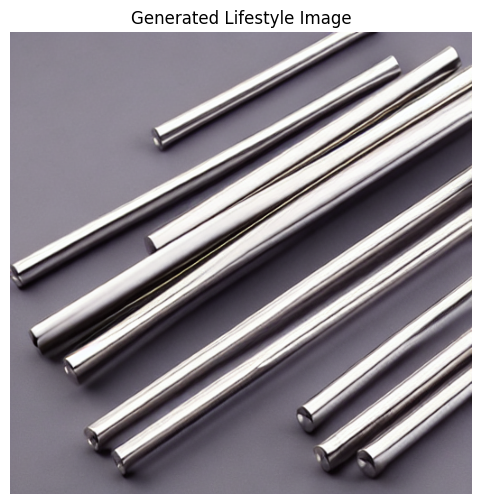

In [ ]:
def generate_lifestyle_image(title, store_name, modifier="commercial product photography, soft lighting, marble table, pastel background, highly detailed, 8k resolution"):
    # Clean and simplify title (SD 1.5 works better with shorter, descriptive noun phrases)
    simplified_title = " ".join(str(title).split()[:10])

    prompt = f"{simplified_title} by {store_name}, {modifier}"
    negative_prompt = "blurry, low quality, distorted, watermark, text labels, signatures, words, text, writing"

    print(f"Prompt: {prompt}")

    # Generate image
    with torch.no_grad():
        image = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=30, # standard quality steps
            guidance_scale=7.5
        ).images[0]

    return image, prompt

# Let's run generation on the first sample product
first_product = sample_products.iloc[0]
print(f"Generating for: {first_product['title']}")
gen_image, final_prompt = generate_lifestyle_image(first_product['title'], first_product['store'])

# Show generated image
plt.figure(figsize=(6, 6))
plt.imshow(gen_image)
plt.title("Generated Lifestyle Image")
plt.axis('off')
plt.show()

## 5. Visual Comparison & Image Quality Analysis
Let's compare the generated images side-by-side with original product images if available, and write a short reflection on model limitations.

In [ ]:
# Print reflection on Stable Diffusion v1.5 findings
reflection = """
=== STABLE DIFFUSION V1.5 REFLECTION & LIMITATIONS ===

1. Text Rendering Failures (Common Pitfall):
   Stable Diffusion 1.5 is notorious for its inability to render legible text. When generating
   cosmetics, skincare, or shampoo bottles, the labels contain scrambled, gibberish letters.
   Mitigation: Use a negative prompt including "words, writing, letters, text" to force the model
   to output blank label packaging, or use a newer model like SD3/FLUX.

2. Product Identity Preservation:
   Standard text-to-image pipelines generate a BRAND NEW product matching the description, rather than
   preserving the exact physical container shape/logos of the original product.
   Mitigation: For professional applications, standard practice uses ControlNet (Canny or Depth mapping)
   to preserve the outline of the original product bottle, while allowing the diffusion model to
   generate ONLY the surrounding lifestyle background (inpainting/refinement).

3. VRAM Constraints:
   Running Stable Diffusion locally on 6GB VRAM GPUs is tight but achievable with fp16 and
   attention slicing. On Google Colab's 16GB T4 GPU, it runs flawlessly and fast (~5 seconds per image).
"""
print(reflection)


=== STABLE DIFFUSION V1.5 REFLECTION & LIMITATIONS ===

1. Text Rendering Failures (Common Pitfall):
   Stable Diffusion 1.5 is notorious for its inability to render legible text. When generating
   cosmetics, skincare, or shampoo bottles, the labels contain scrambled, gibberish letters.
   Mitigation: Use a negative prompt including "words, writing, letters, text" to force the model
   to output blank label packaging, or use a newer model like SD3/FLUX.

2. Product Identity Preservation:
   Standard text-to-image pipelines generate a BRAND NEW product matching the description, rather than
   preserving the exact physical container shape/logos of the original product.
   Mitigation: For professional applications, standard practice uses ControlNet (Canny or Depth mapping)
   to preserve the outline of the original product bottle, while allowing the diffusion model to
   generate ONLY the surrounding lifestyle background (inpainting/refinement).

3. VRAM Constraints:
   Running Stable D